# Calculate IST (Instantaneous Shot Threat)

## Imports

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, roc_auc_score
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from nba_api.stats.static import players

In [3]:
import sys
from pathlib import Path
# Add project root to path for imports
ROOT = Path.cwd().parent  
sys.path.append(str(ROOT))

from src.data_io.maps import load_maps_npz
from src.viz.court import plot_relative_xpps_map, plot_player_map_on_court
from src.utils.players import maps_npz_player_dict
from src.features.ist.features import compute_ist_row, add_ist_column
from src.pipelines.defense_parquet import run_season_pipeline


Loading spatial maps...
Loading shots from: ../data/processed/shots/all_season_shots.parquet


In [4]:
%load_ext autoreload
%autoreload 2

## Load Data

In [5]:
maps, meta = load_maps_npz("../data/processed/shot_maps/maps_1ft_xpps.npz")
nba_players = players.get_players()
print(nba_players[0])

{'id': 76001, 'full_name': 'Alaa Abdelnaby', 'first_name': 'Alaa', 'last_name': 'Abdelnaby', 'is_active': False}


In [6]:
defense_dir =  Path("../data/processed/def_features")
parquet_files = list(defense_dir.glob("*.parquet"))
# merge all parquet files into a single dataframe
df_master = pd.concat((pd.read_parquet(f) for f in parquet_files), ignore_index=True)

/var/folders/gk/9lkdwrfd0hbd5gv7phvzxn440000gn/T/ipykernel_20991/4063134062.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_master = pd.concat((pd.read_parquet(f) for f in parquet_files), ignore_index=True)


In [6]:
# Cap human speed to roughly 25 ft/s (sprint) and -15 ft/s (backpedal)
df_master['w0_closing_speed_mean'] = df_master['w0_closing_speed_mean'].clip(lower=-15.0, upper=25.0)

# You should probably do the same for the shooter's speed just in case:
df_master['w0_shooter_speed_mean'] = df_master['w0_shooter_speed_mean'].clip(lower=0.0, upper=25.0)

In [7]:
pid2row = {int(p): i for i, p in enumerate(maps["player_ids"])}
dist_to_ball = 0.0

In [45]:
maps.keys()
print(f"X range: {maps['xedges'].min()} to {maps['xedges'].max()}")
print(f"Y range: {maps['yedges'].min()} to {maps['yedges'].max()}")

X range: -25.0 to 25.0
Y range: -5.0 to 42.0


In [22]:
maps.keys()

dict_keys(['xedges', 'yedges', 'player_ids', 'attempt_count', 'density', 'quality', 'impact'])

In [8]:
curry_id = 203497
kawhi_id = 202695
league_map  = maps['quality'][pid2row[0]]
curry_map = maps['quality'][pid2row[curry_id]]
kawhi_map = maps['quality'][pid2row[kawhi_id]]

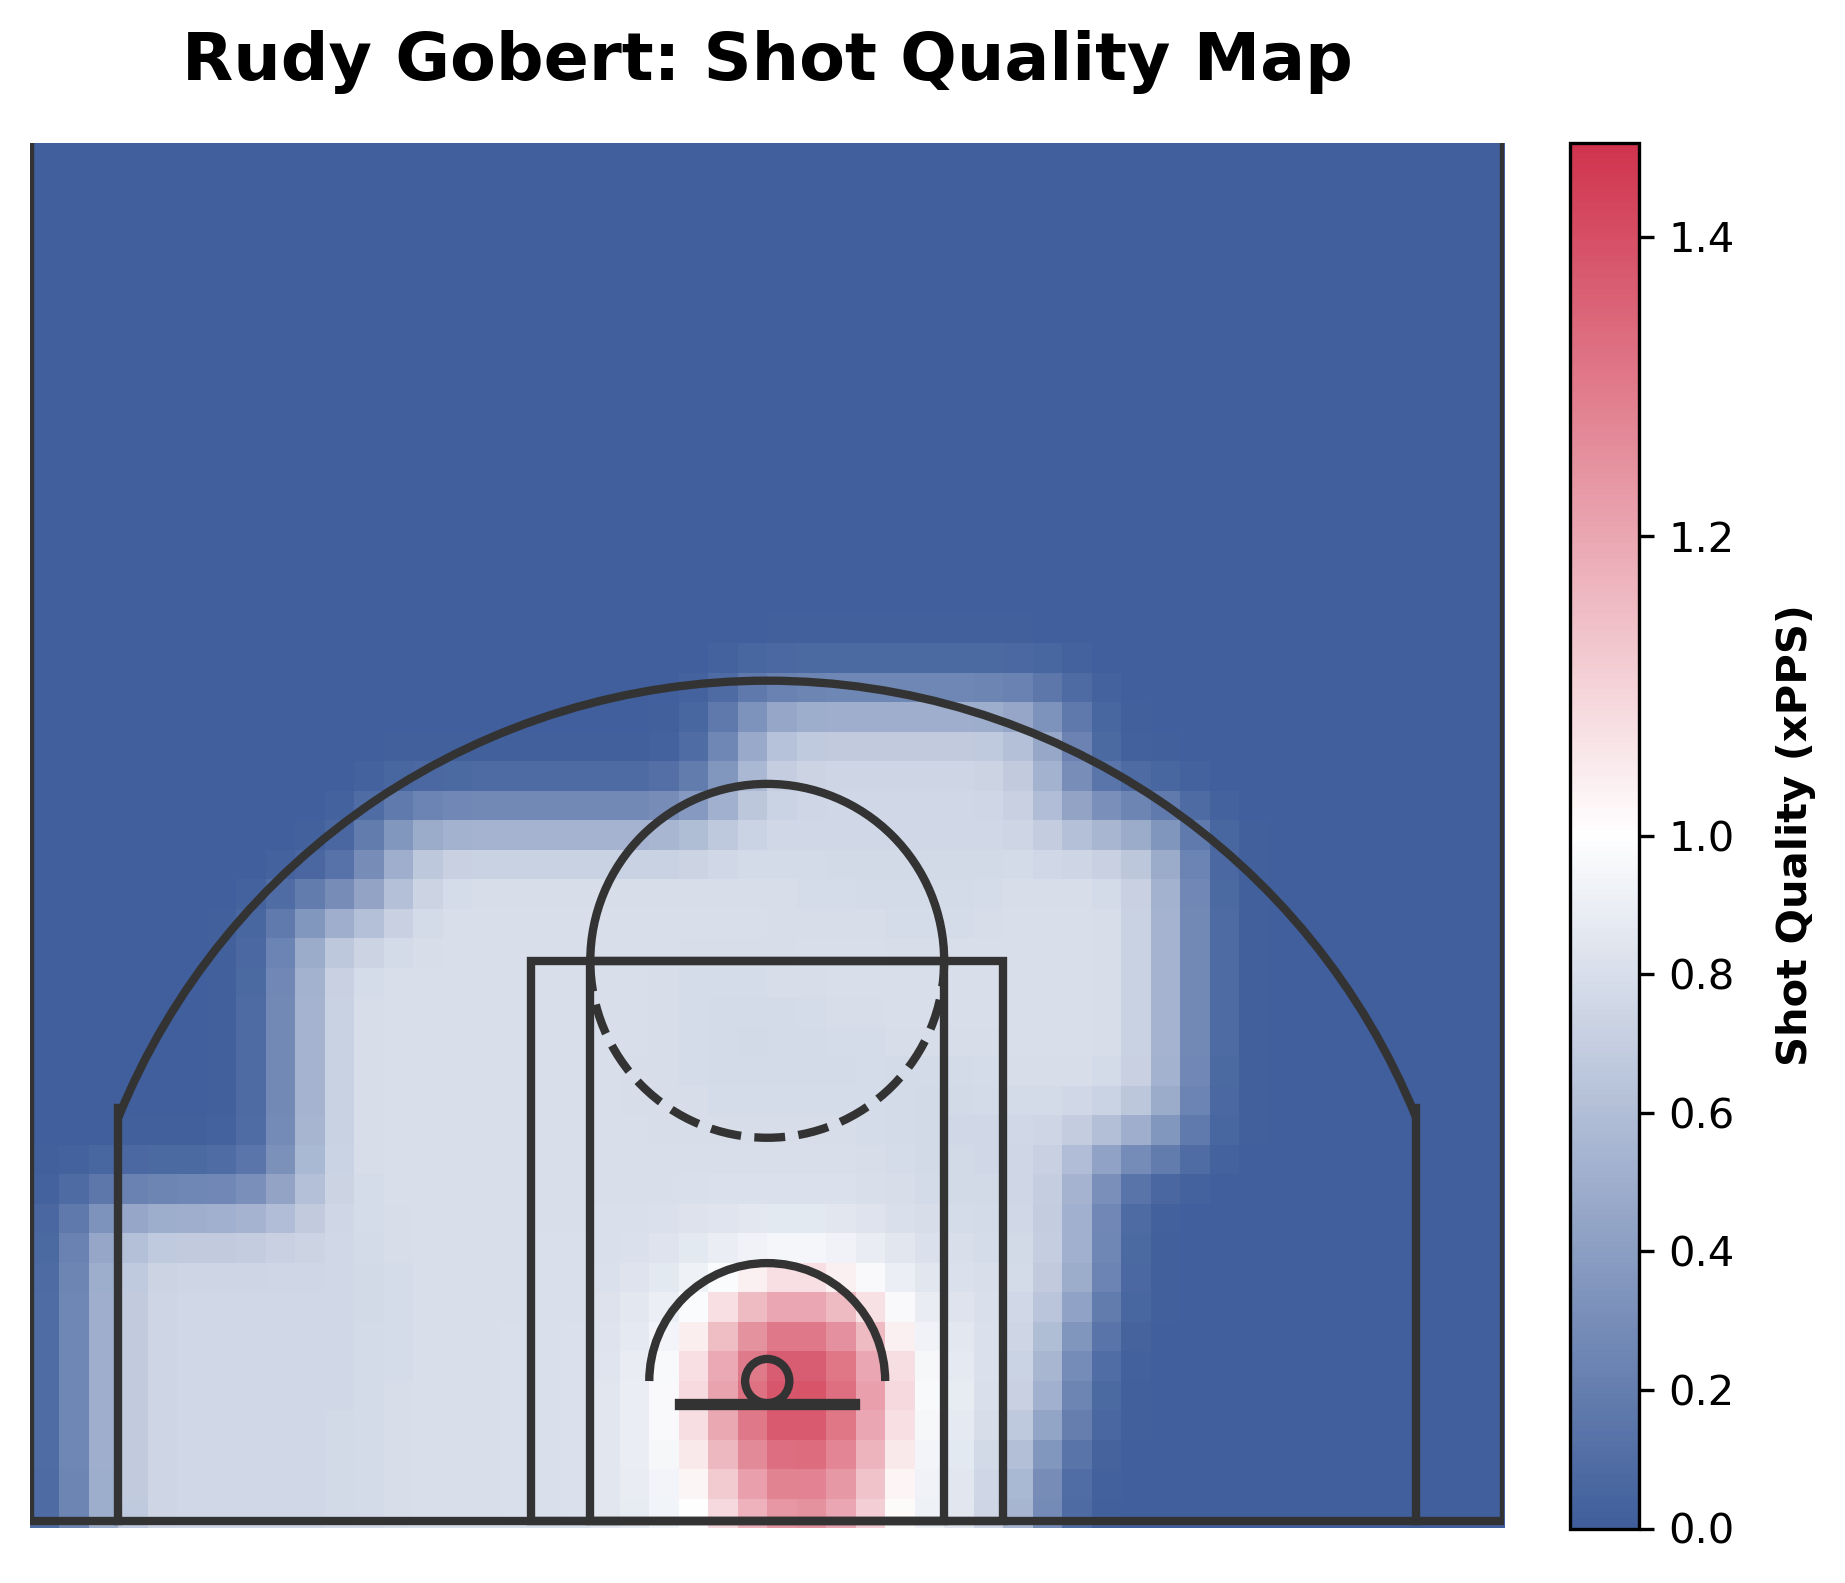

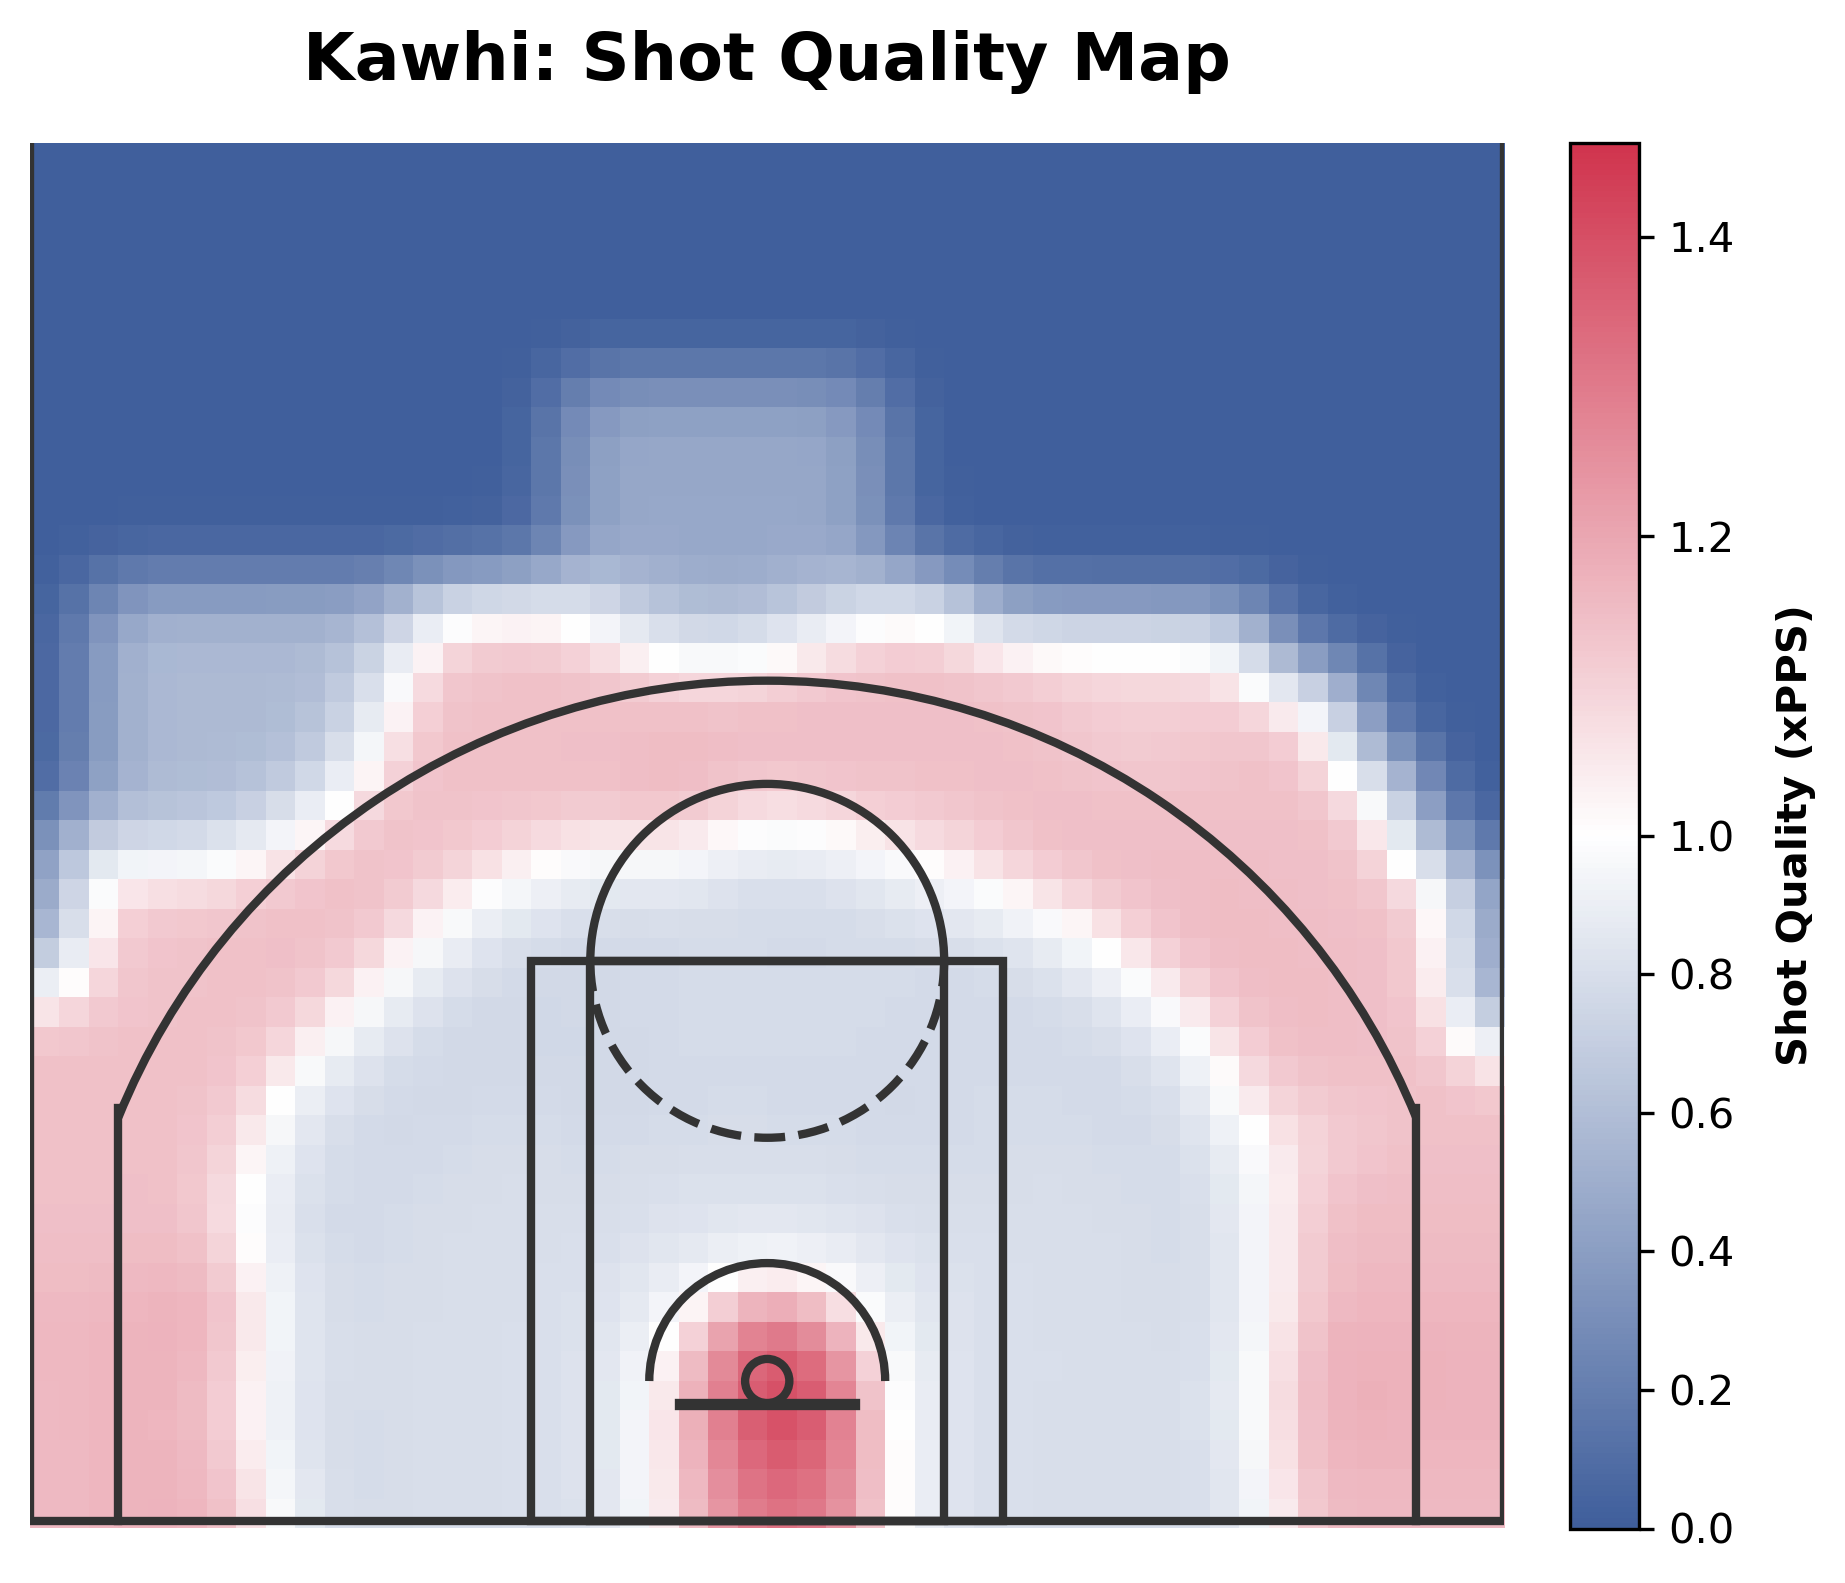

In [15]:
# 1. Establish a shared baseline (1.0 is the standard 'good' vs 'bad' threshold)
baseline = 1.0

# 2. Find the global maximum across both grids to lock the intensity
global_vmax = max(np.max(curry_map), np.max(kawhi_map))

# 3. Plot both using the shared scales
plot_player_map_on_court(curry_map, title="Rudy Gobert: Shot Quality Map", 
                         vmax=global_vmax, midpoint=baseline)

plot_player_map_on_court(kawhi_map, title="Kawhi: Shot Quality Map", 
                         vmax=global_vmax, midpoint=baseline)

In [ ]:
test_shooter = 202695 # Replace with a PLAYER_ID from your data
test_map = maps['quality'][pid2row[test_shooter]]
test_name = [player for player in nba_players if player['id'] == test_shooter][0]['full_name']


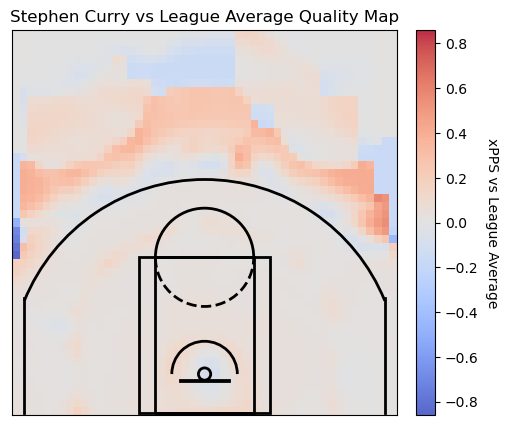

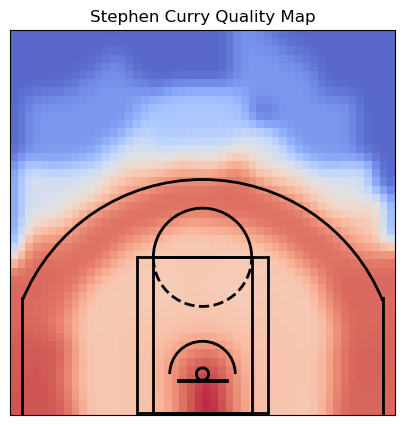

In [78]:
plot_relative_xpps_map(test_map, league_average, title= str(test_name) + " vs League Average Quality Map")
plot_player_map_on_court(test_map, title= str(test_name) + " Quality Map")

## Calculating IST

In [11]:
df_master = add_ist_column(df_master, maps, pid2row)
df_master.columns

TypeError: compute_ist_row() got an unexpected keyword argument 's_speed'. Did you mean 'c_speed'?

### Defining Feature Set

In [ ]:
features = ['Real_Q', 'Real_O', 'Real_S']
df_model = df_master.dropna(subset=features + ['SHOT_MADE_FLAG']).copy()

# Log-Transform the Variables
# We add a tiny epsilon (1e-6) to prevent log(0) errors if O or S perfectly hit 0
epsilon = 1e-6
df_model['ln_Q'] = np.log(df_model['Real_Q'] + epsilon)
df_model['ln_O'] = np.log(df_model['Real_O'] + epsilon)
df_model['ln_S'] = np.log(df_model['Real_S'] + epsilon)

In [ ]:
# 3. Define X (Predictors) and y (Target)
X = df_model[['ln_Q', 'ln_O', 'ln_S']]
y = df_model['SHOT_MADE_FLAG']

### Pipeline

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression(penalty='l2', C=1e9, fit_intercept=True)
log_reg.fit(X_train, y_train)

# 5. Extract the Learned Weights (Exponents)
beta_0 = log_reg.intercept_[0]
beta_Q = log_reg.coef_[0][0]
beta_O = log_reg.coef_[0][1]
beta_S = log_reg.coef_[0][2]

print("--- Empirical IST Weights Learned ---")
print(f"Intercept (beta_0): {beta_0:.4f}")
print(f"Quality Weight (beta_Q): {beta_Q:.4f}")
print(f"Openness Weight (beta_O): {beta_O:.4f}")
print(f"Shootability Weight (beta_S): {beta_S:.4f}")

# 6. Evaluate Model Performance
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]
print("\n--- Model Evaluation ---")
print(f"Log Loss: {log_loss(y_test, y_pred_proba):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# 7. Apply the Learned Formula back to the DataFrame
# IST_empirical = exp(beta_0) * Q^(beta_Q) * O^(beta_O) * S^(beta_S)
df_master['Empirical_IST'] = (
    np.exp(beta_0) * (df_master['Real_Q'] ** beta_Q) * (df_master['Real_O'] ** beta_O) * (df_master['Real_S'] ** beta_S)
)

print("\nEmpirical IST calculated and added to df_master!")

--- Empirical IST Weights Learned ---
Intercept (beta_0): 1.5257
Quality Weight (beta_Q): 2.0621
Openness Weight (beta_O): 0.1004
Shootability Weight (beta_S): -0.0176

--- Model Evaluation ---
Log Loss: 0.6628
ROC AUC: 0.6141

Empirical IST calculated and added to df_master!


In [ ]:
df_master.columns

Index(['GAME_ID', 'SHOT_EVENT_ID', 'tracking_event_id', 'release_frame_idx',
       'event_list_idx', 'PERIOD', 'game_clock', 'PLAYER_ID', 'TEAM_ID',
       'x_ft', 'y_ft', 'xFG_offense', 'xPPS_offense', 'SHOT_MADE_FLAG',
       'close_def_dist_release', 'closest_def_dist', 'close_def_id',
       'num_defenders_tracked', 'w0_close_def_dist_mean',
       'w0_close_def_dist_min', 'w0_shooter_speed_mean',
       'w0_shooter_speed_max', 'w0_def_speed_mean', 'w0_closing_speed_mean',
       'w1_close_def_dist_mean', 'w1_close_def_dist_min',
       'w1_shooter_speed_mean', 'w1_shooter_speed_max', 'w1_def_speed_mean',
       'w1_closing_speed_mean', 'shooter_speed', 'game_clock_tracking',
       'shot_clock_tracking', 'w0_shooter_accel_mean', 'w1_shooter_accel_mean',
       'Real_IST', 'Real_Q', 'Real_O', 'Real_S', 'Empirical_IST'],
      dtype='object')

In [ ]:
# 1. Isolate the necessary raw data (w0 kinematics + Q)
features = [
    'Real_Q', 
    'w0_close_def_dist_mean', 
    'w0_closing_speed_mean', 
    'w0_shooter_speed_mean'
]
df_opt = df_master.dropna(subset=features + ['SHOT_MADE_FLAG']).copy()

# Cap extreme outliers just in case
df_opt['w0_closing_speed_mean'] = df_opt['w0_closing_speed_mean'].clip(lower=-15.0, upper=25.0)
df_opt['w0_shooter_speed_mean'] = df_opt['w0_shooter_speed_mean'].clip(lower=0.0, upper=25.0)

# Convert to numpy arrays for much faster optimization loops
y_true = df_opt['SHOT_MADE_FLAG'].values
Q_raw = df_opt['Real_Q'].values
dist_raw = df_opt['w0_close_def_dist_mean'].values
c_speed_raw = df_opt['w0_closing_speed_mean'].values
s_speed_raw = df_opt['w0_shooter_speed_mean'].values

# We don't optimize accel here to keep the search space clean, but you could add it
s_accel_raw = np.zeros_like(s_speed_raw) 

# 2. Define the Objective Function (Log Loss)
def objective(params):
    # Unpack the parameters being optimized
    # Internal Physics Constants
    d0, k_dist, k_close, v0 = params[0], params[1], params[2], params[3]
    # Logistic Regression Macro-Weights
    beta_0, beta_Q, beta_O, beta_S = params[4], params[5], params[6], params[7]
    
    # Re-calculate O and S on the fly using the new guesses for the constants
    # Openness calculation (with the correct 'positive=closing' logic)
    valid_closing = np.maximum(0.0, c_speed_raw)
    z = k_dist * (dist_raw - d0) - (k_close * valid_closing)
    O = 1.0 / (1.0 + np.exp(-z))
    
    # Shootability calculation
    S = np.exp(-(s_speed_raw / v0)**2)
    
    # Add epsilon to prevent log(0)
    eps = 1e-6
    O = np.clip(O, eps, 1.0)
    S = np.clip(S, eps, 1.0)
    Q = np.clip(Q_raw, eps, 1.0)
    
    # Calculate the Log-Linear combination (the Logistic Regression part)
    log_odds = beta_0 + beta_Q * np.log(Q) + beta_O * np.log(O) + beta_S * np.log(S)
    
    # Convert log-odds to probabilities
    y_pred = 1.0 / (1.0 + np.exp(-log_odds))
    
    # Calculate and return the Log Loss
    return log_loss(y_true, y_pred)

# 3. Set up the Optimization
# Initial Guesses: [d0, k_dist, k_close, v0, beta_0, beta_Q, beta_O, beta_S]
initial_guess = [4.0, 1.2, 0.6, 15.0, 1.4, 2.0, 0.1, 0.1]

# Set STRICT BOUNDS so the physics never break
bounds = [
    (2.0, 6.0),    # d0: Tightly contested distance must be between 2 and 6 feet
    (0.1, 3.0),    # k_dist: Must be positive (distance matters)
    (0.0, 2.0),    # k_close: Must be positive (closing speed matters)
    (8.0, 25.0),   # v0: Shooter speed penalty threshold must be realistic human speed
    (None, None),  # beta_0: Intercept can be anything
    (0.0, 5.0),    # beta_Q: Quality MUST positively correlate to a make
    (0.0, 3.0),    # beta_O: Openness MUST positively correlate to a make (No negative beta_O!)
    (0.0, 3.0)     # beta_S: Shootability MUST positively correlate to a make (No negative beta_S!)
]

# 4. Run the Optimizer
print("Optimizing physics constants and logistic weights...")
result = minimize(objective, initial_guess, bounds=bounds, method='L-BFGS-B')

if result.success:
    print("\n--- Optimization Successful! ---")
    print("Optimal Internal Physics Constants:")
    print(f"  d0 (Contest dist): {result.x[0]:.2f} ft")
    print(f"  k_dist (Dist weight): {result.x[1]:.3f}")
    print(f"  k_close (Close weight): {result.x[2]:.3f}")
    print(f"  v0 (Speed threshold): {result.x[3]:.2f} ft/s")
    
    print("\nOptimal Logistic Regression Weights:")
    print(f"  beta_0 (Intercept): {result.x[4]:.4f}")
    print(f"  beta_Q (Quality): {result.x[5]:.4f}")
    print(f"  beta_O (Openness): {result.x[6]:.4f}")
    print(f"  beta_S (Shootability): {result.x[7]:.4f}")
    
    print(f"\nFinal Minimized Log Loss: {result.fun:.4f}")
else:
    print("Optimization failed:", result.message)

Optimizing physics constants and logistic weights...

--- Optimization Successful! ---
Optimal Internal Physics Constants:
  d0 (Contest dist): 4.80 ft
  k_dist (Dist weight): 0.100
  k_close (Close weight): 0.000
  v0 (Speed threshold): 15.00 ft/s

Optimal Logistic Regression Weights:
  beta_0 (Intercept): 2.1256
  beta_Q (Quality): 2.1631
  beta_O (Openness): 1.0313
  beta_S (Shootability): 0.0000

Final Minimized Log Loss: 0.6593
